In [1]:
# 1. Clone repository & install ONLY missing helper packages
!git clone https://github.com/ahsan-c0ding/S4-Enhancement-Exploration.git
%cd S4-Enhancement-Exploration
!git checkout python

import os
import sys
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

# FIXED: Only install lightweight missing packages (Do NOT reinstall torch/torchvision)
%pip install einops coloredlogs torchinfo --quiet
%pip install git+https://github.com/mwalmsley/galaxy_mnist.git@c1fe9853a00bc34b2ff082585c6bb1654d34d239 --quiet

# Symlink workaround for model_params path resolving
parent_dir = os.path.dirname(current_dir)
_shim_path = os.path.join(parent_dir, "model_params")
_real_path = os.path.join(current_dir, "model_params")
if not os.path.exists(_shim_path) and os.path.exists(_real_path):
    os.symlink(_real_path, _shim_path)

Cloning into 'S4-Enhancement-Exploration'...
remote: Enumerating objects: 1152, done.
remote: Counting objects: 100% (220/220), done.
remote: Compressing objects: 100% (146/146), done.
remote: Total 1152 (delta 88), reused 180 (delta 68), pack-reused 932 (from 2)
Receiving objects: 100% (1152/1152), 94.54 MiB | 27.80 MiB/s, done.
Resolving deltas: 100% (489/489), done.
/kaggle/working/S4-Enhancement-Exploration
Branch 'python' set up to track remote branch 'python' from 'origin'.
Switched to a new branch 'python'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 735.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 1.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.


In [2]:
import math
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from einops import repeat

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_score, recall_score, roc_auc_score

from model.functions import load_data

warnings.filterwarnings("ignore")
sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = [11, 6]

# Reproducibility -- same seed as every other run in this series
RNG_SEED = 30485
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(RNG_SEED)

CLASS_NAMES = ["Smooth Round", "Smooth Cigar", "Edge-on Disk", "Unbarred Spiral"]

# ============================================================================
# PRODUCTION S4D CONFIGURATION (reference values, needed for the runs below)
# ============================================================================
COLORED = True
IN_CHANNELS = 3 if COLORED else 1

S4D_STATE = 256
S4D_NUM_LAYERS = 3
S4D_PATCH_SIZE = 4
S4D_POOLING = "last"
S4D_USE_NORM = False
S4D_USE_RESIDUAL = False
S4D_DROPOUT = 0.2
S4D_PATCH_EMBED = "conv"

S4D_BATCH_SIZE = 32
S4D_FINAL_EPOCHS = 630
LEARNING_RATE = 1e-3

# ============================================================================
# RUN 1: LINEAR-EMBED INTERMEDIATE WIDTH
# ============================================================================
# The two matched-family linear+S4D points so far -- d=72 (35,356 params,
# 80.20% test acc) and d=108 (76,360 params, 78.95% test acc) -- went the
# WRONG direction: more than double the parameters and accuracy dropped. This
# run fills the gap between them at d=90 (~53.9K params, roughly the
# midpoint) to see whether that's a smooth decline, a real dip, or just
# single-seed noise -- same depth/pooling as both endpoints, only width
# changes.
INTERMEDIATE_D = 90
INTERMEDIATE_LAYERS = S4D_NUM_LAYERS   # 3, matching both endpoints
INTERMEDIATE_POOLING = S4D_POOLING     # "last", matching both endpoints
INTERMEDIATE_PATCH_EMBED = "linear"

# ============================================================================
# RUN 2: LINEAR EMBED + S4D + MEAN POOLING (pooling confound, linear side)
# ============================================================================
# We already showed pooling barely matters for conv+S4D (86.80% -> 85.45%,
# -1.35pp). This is the same check for the linear embedding: same d=256,
# 3-layer linear+S4D config as the existing 82.85% result, pooling switched
# from "last" to "mean".
LINEAR_MEANPOOL_D = S4D_STATE            # 256, matches the existing Linear+S4D run
LINEAR_MEANPOOL_LAYERS = S4D_NUM_LAYERS  # 3
LINEAR_MEANPOOL_POOLING = "mean"         # the only thing that changes
LINEAR_MEANPOOL_PATCH_EMBED = "linear"

# ============================================================================
# RUN 3: 64-DIM CONV+S4D RE-RUN (full metrics this time)
# ============================================================================
# The original 64x64-dim run only ever produced a validation accuracy
# (~85%), and those results were lost -- no test accuracy, no F1/precision/
# recall/AUC, no plots. Same config as that original run (conv embed, 3
# layers, d=64, last pooling), re-trained here so we get a full, precise
# test-set readout to compare against the recalled ~85% figure.
D64_RERUN_D = 64
D64_RERUN_LAYERS = S4D_NUM_LAYERS    # 3, matches the original run
D64_RERUN_POOLING = S4D_POOLING      # "last", matches the original run
D64_RERUN_PATCH_EMBED = "conv"

print(f"Device: {DEVICE}")
print(f"Run 1 -- Linear intermediate width: d={INTERMEDIATE_D} | layers={INTERMEDIATE_LAYERS} | pooling={INTERMEDIATE_POOLING} | embed=linear")
print(f"Run 2 -- Linear+S4D mean pool:       d={LINEAR_MEANPOOL_D} | layers={LINEAR_MEANPOOL_LAYERS} | pooling={LINEAR_MEANPOOL_POOLING} | embed=linear")
print(f"Run 3 -- 64-dim conv+S4D re-run:     d={D64_RERUN_D} | layers={D64_RERUN_LAYERS} | pooling={D64_RERUN_POOLING} | embed=conv")


/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Device: cuda
Run 1 -- Linear intermediate width: d=90 | layers=3 | pooling=last | embed=linear
Run 2 -- Linear+S4D mean pool:       d=256 | layers=3 | pooling=mean | embed=linear
Run 3 -- 64-dim conv+S4D re-run:     d=64 | layers=3 | pooling=last | embed=conv


In [3]:
class HilbertScan(nn.Module):
    """Reorders patches of a (B, C, H, W) image along a Hilbert curve."""
    def __init__(self, image_size=64, patch_size=1):
        super().__init__()
        assert image_size % patch_size == 0, "image_size must be divisible by patch_size"
        self.image_size = image_size
        self.patch_size = patch_size
        self.grid_size = image_size // patch_size
        self.num_patches = self.grid_size ** 2
        self.register_buffer("indices", self._get_hilbert_indices(self.grid_size))

    @staticmethod
    def _rot(s, x, y, rx, ry):
        if ry == 0:
            if rx == 1:
                x = s - 1 - x
                y = s - 1 - y
            x, y = y, x
        return x, y

    def _d2xy(self, n, d):
        x = y = 0
        t, s = d, 1
        while s < n:
            rx = (t // 2) & 1
            ry = (t ^ rx) & 1
            x, y = self._rot(s, x, y, rx, ry)
            x += s * rx
            y += s * ry
            t //= 4
            s *= 2
        return x, y

    def _get_hilbert_indices(self, grid_size):
        indices = []
        for d in range(grid_size * grid_size):
            x, y = self._d2xy(grid_size, d)
            indices.append(y * grid_size + x)
        return torch.LongTensor(indices)

    def forward(self, x):
        B, C, H, W = x.shape
        p = self.patch_size
        patches = x.unfold(2, p, p).unfold(3, p, p)
        patches = patches.permute(0, 2, 3, 1, 4, 5).contiguous()
        patches = patches.view(B, self.num_patches, C * p * p)
        return patches[:, self.indices, :]


class TakeLastTimestep(nn.Module):
    def forward(self, x):
        return x[:, -1, :]


class S4DConv(nn.Module):
    """Fast FFT-based parallel convolution S4D layer."""
    def __init__(self, d_model, d_state=64, dt_min=0.001, dt_max=0.1, transposed=True, lr=None):
        super().__init__()
        self.h = d_model
        self.n = d_state
        self.transposed = transposed

        log_dt = torch.rand(self.h) * (math.log(dt_max) - math.log(dt_min)) + math.log(dt_min)
        log_A_real = torch.log(0.5 * torch.ones(self.h, self.n // 2))
        A_imag = math.pi * repeat(torch.arange(self.n // 2), 'n -> h n', h=self.h)
        C_init = torch.randn(self.h, self.n // 2, dtype=torch.cfloat)

        self.register("log_dt", log_dt, lr)
        self.register("log_A_real", log_A_real, lr)
        self.register("A_imag", A_imag, lr)

        self.C = nn.Parameter(torch.view_as_real(C_init))
        self.D = nn.Parameter(torch.randn(self.h))

    def register(self, name, tensor, lr=None):
        if lr == 0.0:
            self.register_buffer(name, tensor)
        else:
            self.register_parameter(name, nn.Parameter(tensor))
            optim = {"weight_decay": 0.0}
            if lr is not None:
                optim["lr"] = lr
            setattr(getattr(self, name), "_optim", optim)

    def forward(self, u):
        if not self.transposed:
            u = u.transpose(-1, -2)
        L = u.size(-1)

        dt = torch.exp(self.log_dt)
        C = torch.view_as_complex(self.C)
        A = -torch.exp(self.log_A_real) + 1j * self.A_imag

        dtA = A * dt.unsqueeze(-1)
        K_exp = torch.exp(dtA.unsqueeze(-1) * torch.arange(L, device=u.device))
        C_tilde = C * (torch.exp(dtA) - 1.) / A
        k = 2 * torch.einsum('hn, hnl -> hl', C_tilde, K_exp).real

        k_f = torch.fft.rfft(k, n=2 * L)
        u_f = torch.fft.rfft(u, n=2 * L)
        y = torch.fft.irfft(u_f * k_f, n=2 * L)[..., :L]
        y = y + u * self.D.unsqueeze(-1)

        if not self.transposed:
            y = y.transpose(-1, -2)
        return y, None


class ConvPatchStem(nn.Module):
    """Convolutional stem for local neighborhood mixing before patch projection."""
    def __init__(self, in_channels, d_model, patch_size):
        super().__init__()
        mid_channels = max(in_channels * 8, 32)
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, stride=1, padding=1),
            nn.GELU(),
            nn.Conv2d(mid_channels, d_model, kernel_size=patch_size, stride=patch_size),
        )

    def forward(self, x):
        return self.net(x)


class GalaxyClassifierS4DFast(nn.Module):
    """Production S4D Classifier."""
    def __init__(self, s4_state=64, d_model=64, num_classes=4, colored=True,
                 num_layers=2, patch_size=1, pooling="last",
                 use_norm=False, use_residual=False, dropout=0.0,
                 patch_embed="linear"):
        super().__init__()
        self.hilbert_channels = 1 if not colored else 3
        self.patch_size = patch_size
        self.pooling = pooling
        self.use_norm = use_norm
        self.use_residual = use_residual
        self.patch_embed = patch_embed

        if patch_embed == "linear":
            self.hilbert_scan = HilbertScan(image_size=64, patch_size=patch_size)
            patch_dim = self.hilbert_channels * patch_size * patch_size
            self.uproject = nn.Linear(patch_dim, d_model)
            self.conv_stem = None
        elif patch_embed == "conv":
            self.conv_stem = ConvPatchStem(self.hilbert_channels, d_model, patch_size)
            self.hilbert_scan = HilbertScan(image_size=64 // patch_size, patch_size=1)
            self.uproject = nn.Identity()

        self.s4_layers = nn.ModuleList([
            S4DConv(d_model=d_model, d_state=s4_state, transposed=False)
            for _ in range(num_layers)
        ])
        self.acts = nn.ModuleList([nn.GELU() for _ in range(num_layers)])
        self.norms = nn.ModuleList([nn.LayerNorm(d_model) for _ in range(num_layers)]) if use_norm else None
        self.drop = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        if pooling == "last":
            self.take_last = TakeLastTimestep()
        elif pooling == "mean":
            self.take_last = None
        else:
            raise ValueError(f"Unknown pooling type {pooling}")

        self.fc = nn.Linear(d_model, num_classes)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x, return_logits=True):
        if self.patch_embed == "conv":
            feat = self.conv_stem(x)
            x_seq = self.hilbert_scan(feat)
            h = self.uproject(x_seq)
        else:
            x_seq = self.hilbert_scan(x)
            h = self.uproject(x_seq)

        for i, (s4_layer, act) in enumerate(zip(self.s4_layers, self.acts)):
            residual = h
            h_in = self.norms[i](h) if self.use_norm else h
            h_out, _ = s4_layer(h_in)
            h_out = act(h_out)
            h_out = self.drop(h_out)
            h = residual + h_out if self.use_residual else h_out

        pooled = h.mean(dim=1) if self.take_last is None else self.take_last(h)
        logits = self.fc(pooled)

        if return_logits:
            return logits
        return self.softmax(logits)

In [4]:
# Load dataset
X, y_onehot, y = load_data(root="./data", download=True, train=True, colored=COLORED)
X_test, y_test_onehot, y_test = load_data(root="./data", download=True, train=False, colored=COLORED)
NUM_CLASSES = y_onehot.shape[1]

# FIXED: Unpack 4 outputs corresponding to passing X and y
x_train, x_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RNG_SEED, stratify=y
)

# Custom dataset supporting rotation and flip augmentation
class GalaxyDataset(Dataset):
    def __init__(self, images, labels, augment=False):
        self.images = images
        self.labels = labels
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        lbl = self.labels[idx]
        if self.augment:
            # Random orthogonal rotation
            k = random.randint(0, 3)
            img = torch.rot90(img, k, [1, 2])
            # Random flips
            if random.random() > 0.5:
                img = torch.flip(img, [2])
            if random.random() > 0.5:
                img = torch.flip(img, [1])
        return img, lbl

train_dataset = GalaxyDataset(x_train, y_train, augment=True)
val_dataset = GalaxyDataset(x_val, y_val, augment=False)
test_dataset = GalaxyDataset(X_test, y_test, augment=False)

train_loader = DataLoader(train_dataset, batch_size=S4D_BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=S4D_BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=S4D_BATCH_SIZE, shuffle=False)

print(f"Data Split -> Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

100%|██████████| 68.7M/68.7M [00:06<00:00, 10.3MB/s]
100%|██████████| 17.3M/17.3M [00:02<00:00, 5.83MB/s]


Original Dataset Size: 8000 samples
Original Dataset Size: 2000 samples
Data Split -> Train: 6400 | Val: 1600 | Test: 2000


In [5]:
def create_s4d_optimizer(model, lr=1e-3, weight_decay=0.01):
    decay_params, no_decay_params, special_params = [], [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if hasattr(param, "_optim"):
            opt_dict = param._optim
            param_lr = opt_dict.get("lr", lr)
            special_params.append({'params': [param], 'lr': param_lr, 'weight_decay': 0.0})
        elif any(k in name for k in ["bias", "norm", "LayerNorm"]):
            no_decay_params.append(param)
        else:
            decay_params.append(param)

    groups = [
        {'params': decay_params, 'weight_decay': weight_decay, 'lr': lr},
        {'params': no_decay_params, 'weight_decay': 0.0, 'lr': lr},
    ] + special_params
    return torch.optim.AdamW(groups)


def train_s4d_production(model, train_loader, val_loader, epochs=S4D_FINAL_EPOCHS, lr=LEARNING_RATE, device=DEVICE, ckpt_name="s4d_production_best.pt"):
    model.to(device)
    optimizer = create_s4d_optimizer(model, lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-5
    )
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0.0
    os.makedirs("checkpoints", exist_ok=True)
    best_ckpt_path = f"checkpoints/{ckpt_name}"  # parametrized so different runs don't clobber each other's checkpoint

    start_time = time.time()
    print(f"Starting S4D production training for {epochs} epochs...")

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(images, return_logits=True)
            loss = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            correct += (logits.argmax(-1) == labels).sum().item()
            total += labels.size(0)

        scheduler.step()
        train_loss = running_loss / total
        train_acc = correct / total

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                logits = model(images, return_logits=True)
                val_correct += (logits.argmax(-1) == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_ckpt_path)

        if (epoch + 1) % 25 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch+1:03d}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} (Best: {best_val_acc:.4f})")

    elapsed = time.time() - start_time
    print(f"\nTraining completed in {elapsed/60:.2f} mins. Best Validation Accuracy: {best_val_acc*100:.2f}%")
    
    # Load best checkpoint
    model.load_state_dict(torch.load(best_ckpt_path))
    return model, history


def evaluate_on_test(model, test_loader, device=DEVICE):
    """Runs a trained model on the test set and returns every metric we report."""
    model.eval()
    all_preds, all_targets, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            probs = model(images, return_logits=False)
            preds = probs.argmax(-1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    all_probs = np.array(all_probs)
    return {
        "accuracy": accuracy_score(all_targets, all_preds),
        "f1": f1_score(all_targets, all_preds, average="macro"),
        "precision": precision_score(all_targets, all_preds, average="macro"),
        "recall": recall_score(all_targets, all_preds, average="macro"),
        "auc": roc_auc_score(all_targets, all_probs, multi_class="ovr", average="macro"),
        "preds": all_preds,
        "targets": all_targets,
    }


In [6]:
# Run 1: linear embed, intermediate width (d=90), S4D on -- fills the gap
# between the d=72 (80.20%) and d=108 (78.95%) results.
intermediate_linear_model = GalaxyClassifierS4DFast(
    s4_state=INTERMEDIATE_D,
    d_model=INTERMEDIATE_D,
    num_classes=NUM_CLASSES,
    colored=COLORED,
    num_layers=INTERMEDIATE_LAYERS,
    patch_size=S4D_PATCH_SIZE,
    pooling=INTERMEDIATE_POOLING,
    use_norm=S4D_USE_NORM,
    use_residual=S4D_USE_RESIDUAL,
    dropout=S4D_DROPOUT,
    patch_embed=INTERMEDIATE_PATCH_EMBED
)

best_intermediate_linear_model, intermediate_linear_history = train_s4d_production(
    intermediate_linear_model, train_loader, val_loader,
    epochs=S4D_FINAL_EPOCHS, ckpt_name="linear_intermediate_d90_best.pt"
)


Starting S4D production training for 630 epochs...
Epoch 025/630 | Train Loss: 0.7160 | Train Acc: 0.6947 | Val Acc: 0.7375 (Best: 0.7394)
Epoch 050/630 | Train Loss: 0.6526 | Train Acc: 0.7194 | Val Acc: 0.7469 (Best: 0.7569)
Epoch 075/630 | Train Loss: 0.6338 | Train Acc: 0.7300 | Val Acc: 0.7581 (Best: 0.7662)
Epoch 100/630 | Train Loss: 0.5868 | Train Acc: 0.7445 | Val Acc: 0.7619 (Best: 0.7719)
Epoch 125/630 | Train Loss: 0.5574 | Train Acc: 0.7616 | Val Acc: 0.7675 (Best: 0.7788)
Epoch 150/630 | Train Loss: 0.5458 | Train Acc: 0.7639 | Val Acc: 0.7738 (Best: 0.7788)
Epoch 175/630 | Train Loss: 0.5516 | Train Acc: 0.7680 | Val Acc: 0.7775 (Best: 0.7906)
Epoch 200/630 | Train Loss: 0.5267 | Train Acc: 0.7775 | Val Acc: 0.7756 (Best: 0.7906)
Epoch 225/630 | Train Loss: 0.5057 | Train Acc: 0.7833 | Val Acc: 0.7937 (Best: 0.7963)
Epoch 250/630 | Train Loss: 0.4977 | Train Acc: 0.7848 | Val Acc: 0.7913 (Best: 0.7981)
Epoch 275/630 | Train Loss: 0.4813 | Train Acc: 0.7916 | Val Acc: 0.7

In [7]:
# Run 2: linear embed, d=256, 3 layers, S4D on, mean pooling instead of last.
linear_meanpool_model = GalaxyClassifierS4DFast(
    s4_state=LINEAR_MEANPOOL_D,
    d_model=LINEAR_MEANPOOL_D,
    num_classes=NUM_CLASSES,
    colored=COLORED,
    num_layers=LINEAR_MEANPOOL_LAYERS,
    patch_size=S4D_PATCH_SIZE,
    pooling=LINEAR_MEANPOOL_POOLING,
    use_norm=S4D_USE_NORM,
    use_residual=S4D_USE_RESIDUAL,
    dropout=S4D_DROPOUT,
    patch_embed=LINEAR_MEANPOOL_PATCH_EMBED
)

best_linear_meanpool_model, linear_meanpool_history = train_s4d_production(
    linear_meanpool_model, train_loader, val_loader,
    epochs=S4D_FINAL_EPOCHS, ckpt_name="linear_s4d_meanpool_best.pt"
)


Starting S4D production training for 630 epochs...
Epoch 025/630 | Train Loss: 0.6851 | Train Acc: 0.7025 | Val Acc: 0.7200 (Best: 0.7225)
Epoch 050/630 | Train Loss: 0.6152 | Train Acc: 0.7370 | Val Acc: 0.7250 (Best: 0.7500)
Epoch 075/630 | Train Loss: 0.6015 | Train Acc: 0.7330 | Val Acc: 0.7144 (Best: 0.7500)
Epoch 100/630 | Train Loss: 0.5703 | Train Acc: 0.7506 | Val Acc: 0.7388 (Best: 0.7544)
Epoch 125/630 | Train Loss: 0.5271 | Train Acc: 0.7742 | Val Acc: 0.7638 (Best: 0.7725)
Epoch 150/630 | Train Loss: 0.5198 | Train Acc: 0.7777 | Val Acc: 0.7669 (Best: 0.7725)
Epoch 175/630 | Train Loss: 0.5103 | Train Acc: 0.7845 | Val Acc: 0.7650 (Best: 0.7769)
Epoch 200/630 | Train Loss: 0.4849 | Train Acc: 0.7920 | Val Acc: 0.7794 (Best: 0.7875)
Epoch 225/630 | Train Loss: 0.4569 | Train Acc: 0.8037 | Val Acc: 0.7881 (Best: 0.7925)
Epoch 250/630 | Train Loss: 0.4510 | Train Acc: 0.8075 | Val Acc: 0.7844 (Best: 0.7969)
Epoch 275/630 | Train Loss: 0.4320 | Train Acc: 0.8072 | Val Acc: 0.7

In [8]:
# Run 3: conv embed, d=64, 3 layers, S4D on, last pooling -- re-run of the
# original 64x64-dim model so we get real test-set metrics this time.
d64_rerun_model = GalaxyClassifierS4DFast(
    s4_state=D64_RERUN_D,
    d_model=D64_RERUN_D,
    num_classes=NUM_CLASSES,
    colored=COLORED,
    num_layers=D64_RERUN_LAYERS,
    patch_size=S4D_PATCH_SIZE,
    pooling=D64_RERUN_POOLING,
    use_norm=S4D_USE_NORM,
    use_residual=S4D_USE_RESIDUAL,
    dropout=S4D_DROPOUT,
    patch_embed=D64_RERUN_PATCH_EMBED
)

best_d64_rerun_model, d64_rerun_history = train_s4d_production(
    d64_rerun_model, train_loader, val_loader,
    epochs=S4D_FINAL_EPOCHS, ckpt_name="d64_rerun_best.pt"
)


Starting S4D production training for 630 epochs...
Epoch 025/630 | Train Loss: 0.6903 | Train Acc: 0.7106 | Val Acc: 0.7462 (Best: 0.7462)
Epoch 050/630 | Train Loss: 0.6158 | Train Acc: 0.7338 | Val Acc: 0.7638 (Best: 0.7638)
Epoch 075/630 | Train Loss: 0.6009 | Train Acc: 0.7419 | Val Acc: 0.7675 (Best: 0.7738)
Epoch 100/630 | Train Loss: 0.5287 | Train Acc: 0.7752 | Val Acc: 0.7831 (Best: 0.8006)
Epoch 125/630 | Train Loss: 0.4879 | Train Acc: 0.7909 | Val Acc: 0.8044 (Best: 0.8063)
Epoch 150/630 | Train Loss: 0.4649 | Train Acc: 0.8047 | Val Acc: 0.8100 (Best: 0.8119)
Epoch 175/630 | Train Loss: 0.4756 | Train Acc: 0.7997 | Val Acc: 0.8069 (Best: 0.8125)
Epoch 200/630 | Train Loss: 0.4473 | Train Acc: 0.8103 | Val Acc: 0.8100 (Best: 0.8225)
Epoch 225/630 | Train Loss: 0.4355 | Train Acc: 0.8183 | Val Acc: 0.8150 (Best: 0.8250)
Epoch 250/630 | Train Loss: 0.4050 | Train Acc: 0.8258 | Val Acc: 0.8200 (Best: 0.8281)
Epoch 275/630 | Train Loss: 0.3971 | Train Acc: 0.8308 | Val Acc: 0.8

Linear+S4D Intermediate Width (d=90) -- Test Set Results
Accuracy:        80.10%
Macro-F1:        0.8016
Macro-Precision: 0.8022
Macro-Recall:    0.8017
Macro-AUC (OVR): 0.9578

Linear+S4D Mean Pool (d=256) -- Test Set Results
Accuracy:        82.20%
Macro-F1:        0.8210
Macro-Precision: 0.8219
Macro-Recall:    0.8228
Macro-AUC (OVR): 0.9618

64-dim Conv+S4D Re-run -- Test Set Results
Accuracy:        84.20%
Macro-F1:        0.8425
Macro-Precision: 0.8431
Macro-Recall:    0.8423
Macro-AUC (OVR): 0.9705



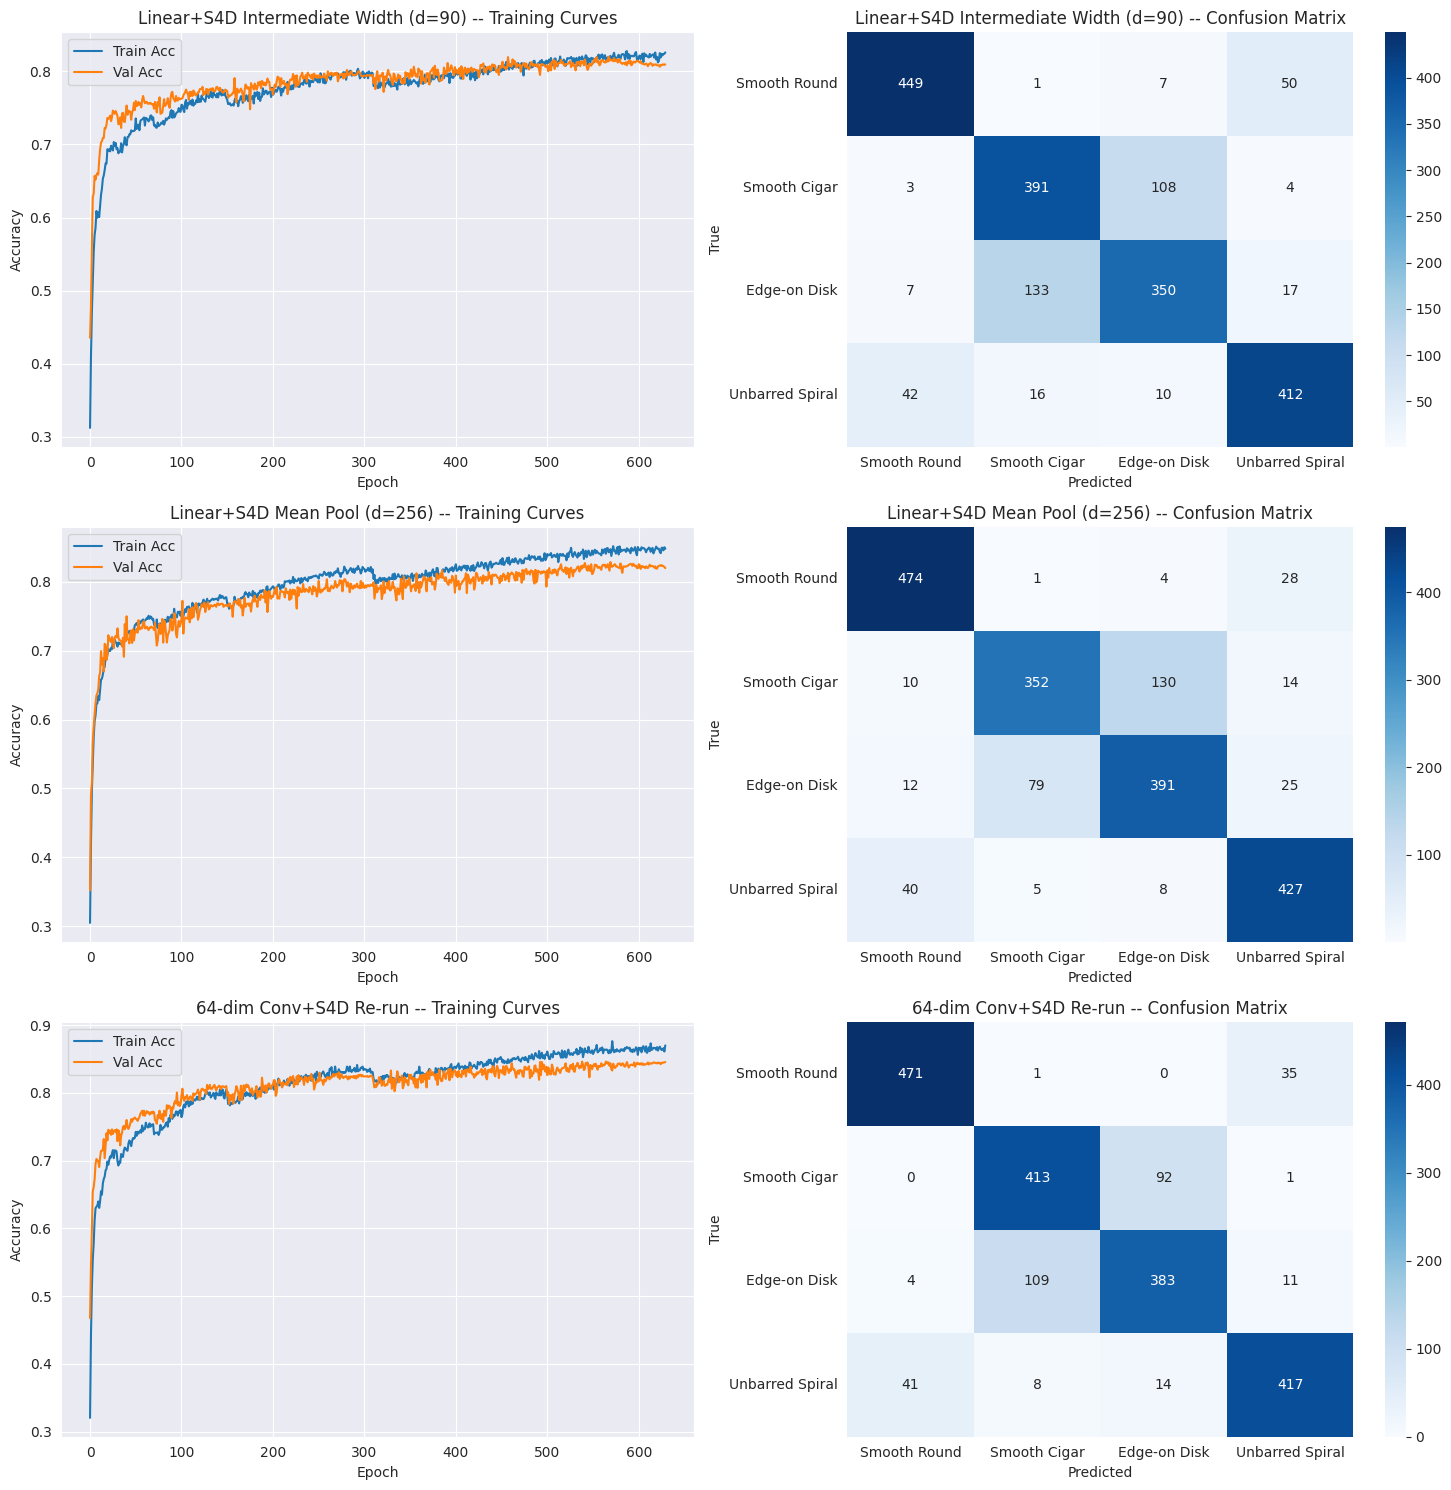

In [9]:
runs = [
    ("Linear+S4D Intermediate Width (d=90)", best_intermediate_linear_model, intermediate_linear_history),
    ("Linear+S4D Mean Pool (d=256)", best_linear_meanpool_model, linear_meanpool_history),
    ("64-dim Conv+S4D Re-run", best_d64_rerun_model, d64_rerun_history),
]

results = {}
for name, model, history in runs:
    res = evaluate_on_test(model, test_loader)
    results[name] = res
    print("=" * 50)
    print(f"{name} -- Test Set Results")
    print("=" * 50)
    print(f"Accuracy:        {res['accuracy'] * 100:.2f}%")
    print(f"Macro-F1:        {res['f1']:.4f}")
    print(f"Macro-Precision: {res['precision']:.4f}")
    print(f"Macro-Recall:    {res['recall']:.4f}")
    print(f"Macro-AUC (OVR): {res['auc']:.4f}")
    print("=" * 50)
    print()

# Training curves + confusion matrices, all three runs stacked
fig, axes = plt.subplots(3, 2, figsize=(15, 15))

for i, (name, model, history) in enumerate(runs):
    axes[i, 0].plot(history["train_acc"], label="Train Acc")
    axes[i, 0].plot(history["val_acc"], label="Val Acc")
    axes[i, 0].set_title(f"{name} -- Training Curves")
    axes[i, 0].set_xlabel("Epoch")
    axes[i, 0].set_ylabel("Accuracy")
    axes[i, 0].legend()

    res = results[name]
    cm = confusion_matrix(res["targets"], res["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[i, 1])
    axes[i, 1].set_title(f"{name} -- Confusion Matrix")
    axes[i, 1].set_xlabel("Predicted")
    axes[i, 1].set_ylabel("True")

plt.tight_layout()
plt.show()


In [10]:
from torchinfo import summary

def count_params(model):
    return sum(p.numel() for p in model.parameters())

param_counts = {
    "Linear+S4D Intermediate Width (d=90)": count_params(best_intermediate_linear_model),
    "Linear+S4D Mean Pool (d=256)": count_params(best_linear_meanpool_model),
    "64-dim Conv+S4D Re-run": count_params(best_d64_rerun_model),
}

for name, n in param_counts.items():
    print(f"{name:42s} {n:>10,} params")

print("\nFull layer-by-layer breakdown -- Linear+S4D Intermediate Width (d=90):")
summary(best_intermediate_linear_model, input_size=(S4D_BATCH_SIZE, IN_CHANNELS, 64, 64))


Linear+S4D Intermediate Width (d=90)           53,914 params
Linear+S4D Mean Pool (d=256)                  408,324 params
64-dim Conv+S4D Re-run                         58,948 params

Full layer-by-layer breakdown -- Linear+S4D Intermediate Width (d=90):


Layer (type:depth-idx)                   Output Shape              Param #
GalaxyClassifierS4DFast                  [32, 4]                   --
├─HilbertScan: 1-1                       [32, 256, 48]             --
├─Linear: 1-2                            [32, 256, 90]             4,410
├─ModuleList: 1-9                        --                        (recursive)
│    └─S4DConv: 2-1                      [32, 256, 90]             16,380
├─ModuleList: 1-10                       --                        --
│    └─GELU: 2-2                         [32, 256, 90]             --
├─Dropout: 1-5                           [32, 256, 90]             --
├─ModuleList: 1-9                        --                        (recursive)
│    └─S4DConv: 2-3                      [32, 256, 90]             16,380
├─ModuleList: 1-10                       --                        --
│    └─GELU: 2-4                         [32, 256, 90]             --
├─Dropout: 1-8                           [32, 256, 90]  

In [11]:
import shutil
from IPython.display import FileLink, display

ckpt_names = ["linear_intermediate_d90_best.pt", "linear_s4d_meanpool_best.pt", "d64_rerun_best.pt"]

for ckpt_name in ckpt_names:
    source_path = f"checkpoints/{ckpt_name}"
    destination_path = f"/kaggle/working/{ckpt_name}"
    if os.path.exists(source_path):
        shutil.copy(source_path, destination_path)
        print(f"✅ {ckpt_name} moved to the root output folder!")
    else:
        print(f"❌ Could not find {ckpt_name} -- did training complete?")

print("\nClick the links below to download your weights:")
os.chdir('/kaggle/working')
for ckpt_name in ckpt_names:
    if os.path.exists(ckpt_name):
        display(FileLink(ckpt_name))
os.chdir('/kaggle/working/S4-Enhancement-Exploration')


✅ linear_intermediate_d90_best.pt moved to the root output folder!
✅ linear_s4d_meanpool_best.pt moved to the root output folder!
✅ d64_rerun_best.pt moved to the root output folder!

Click the links below to download your weights:


/kaggle/working/linear_intermediate_d90_best.pt

/kaggle/working/linear_s4d_meanpool_best.pt

/kaggle/working/d64_rerun_best.pt

In [12]:
# ============================================================================
# SUMMARY -- three targeted follow-ups from the report review
# ============================================================================
intermediate_res = results["Linear+S4D Intermediate Width (d=90)"]
meanpool_res = results["Linear+S4D Mean Pool (d=256)"]
d64_res = results["64-dim Conv+S4D Re-run"]

summary_rows = [
    {"Model": "Linear+S4D (d=72)", "Params": 35_356, "Accuracy": 0.8020, "AUC": 0.9562},
    {"Model": "Linear+S4D (d=90) [NEW]", "Params": param_counts["Linear+S4D Intermediate Width (d=90)"],
     "Accuracy": intermediate_res["accuracy"], "AUC": intermediate_res["auc"]},
    {"Model": "Linear+S4D (d=108)", "Params": 76_360, "Accuracy": 0.7895, "AUC": 0.9551},
]
width_df = pd.DataFrame(summary_rows).set_index("Model")
width_df["Accuracy"] = width_df["Accuracy"].map(lambda x: f"{x*100:.2f}%")
width_df["AUC"] = width_df["AUC"].map(lambda x: f"{x:.4f}")
width_df["Params"] = width_df["Params"].map(lambda x: f"{x:,}")

print("=" * 60)
print("WIDTH SCAN CHECK (linear embed, S4D on, 3 layers)")
print("=" * 60)
print(width_df.to_string())

acc_72, acc_90, acc_108 = 0.8020, intermediate_res["accuracy"], 0.7895
if acc_72 >= acc_90 >= acc_108:
    print("\nMonotonic decline across d=72 -> 90 -> 108: looks like a real (if small) downward")
    print("trend with width for the linear embedding, not just noise at the endpoints.")
elif acc_90 > acc_72 or acc_90 < acc_108:
    print("\nNon-monotonic: d=90 breaks the trend implied by the two endpoints, which points")
    print("toward single-seed noise rather than a genuine width effect. Repeat seeds would")
    print("be the next step to confirm either way.")
else:
    print("\nResult sits between the two endpoints without being strictly monotonic --")
    print("inconclusive on its own; repeat seeds would help settle it.")

print("\n" + "=" * 60)
print("LINEAR EMBED POOLING CONFOUND CHECK")
print("=" * 60)
linear_last_acc = 0.8285
linear_mean_acc = meanpool_res["accuracy"]
print(f"Linear+S4D, last-pool (existing): {linear_last_acc*100:.2f}%")
print(f"Linear+S4D, mean-pool (this run): {linear_mean_acc*100:.2f}%")
print(f"Difference:                       {(linear_last_acc - linear_mean_acc)*100:+.2f} pp")
print("Small difference -> pooling doesn't confound the linear-embed comparisons either,")
print("consistent with what we already found for conv embed (+1.35pp there).")

print("\n" + "=" * 60)
print("64-DIM MODEL: RECALLED VALIDATION FIGURE VS. FRESH TEST RESULT")
print("=" * 60)
historical_val_acc = 0.8500
fresh_test_acc = d64_res["accuracy"]
print(f"Historical figure (validation, recalled, not logged): {historical_val_acc*100:.2f}%")
print(f"This run (test set, full metrics):                    {fresh_test_acc*100:.2f}%")
print(f"Macro-F1:        {d64_res['f1']:.4f}")
print(f"Macro-Precision: {d64_res['precision']:.4f}")
print(f"Macro-Recall:    {d64_res['recall']:.4f}")
print(f"Macro-AUC (OVR): {d64_res['auc']:.4f}")
print(f"Params:          {param_counts['64-dim Conv+S4D Re-run']:,}")
print(f"\nGap vs. recalled figure: {(fresh_test_acc - historical_val_acc)*100:+.2f}pp")
print("(val and test accuracy aren't the same metric, so some gap is expected either way --")
print("this replaces the asterisked row in the report with a real, fully-measured result.)")


WIDTH SCAN CHECK (linear embed, S4D on, 3 layers)
                         Params Accuracy     AUC
Model                                           
Linear+S4D (d=72)        35,356   80.20%  0.9562
Linear+S4D (d=90) [NEW]  53,914   80.10%  0.9578
Linear+S4D (d=108)       76,360   78.95%  0.9551

Monotonic decline across d=72 -> 90 -> 108: looks like a real (if small) downward
trend with width for the linear embedding, not just noise at the endpoints.

LINEAR EMBED POOLING CONFOUND CHECK
Linear+S4D, last-pool (existing): 82.85%
Linear+S4D, mean-pool (this run): 82.20%
Difference:                       +0.65 pp
Small difference -> pooling doesn't confound the linear-embed comparisons either,
consistent with what we already found for conv embed (+1.35pp there).

64-DIM MODEL: RECALLED VALIDATION FIGURE VS. FRESH TEST RESULT
Historical figure (validation, recalled, not logged): 85.00%
This run (test set, full metrics):                    84.20%
Macro-F1:        0.8425
Macro-Precision: 0.843